# Kernel Approximations: Nyström, Random Fourier Features, and Kernel Statistics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/kernel_approximations.ipynb)

Full kernel matrices cost $O(N^2)$ memory and $O(N^3)$ time to factorize. This notebook builds the two standard low-rank approximations with kernellib, solves a GP regression problem through one of them with gaussx, and then uses kernellib's matrix-level statistics for independence and two-sample testing.

**What you'll learn:**

1. Building kernel matrices from kernel objects such as `kl.RBF`
2. Nyström and random Fourier feature (RFF) approximations as `LowRankUpdate` operators
3. Solving a noisy system through a low-rank operator with `gaussx.solve`
4. Kernel centering, HSIC (biased and unbiased), CKA, and MMD from `kernellib.functional`

## Background

**Nyström approximation.** Given $N$ data points and $M \ll N$ inducing (landmark) points $Z$, the Nyström method approximates the full kernel matrix as

$$K_{ff} \approx Q_{ff} = K_{fM} K_{MM}^{-1} K_{Mf}$$

This is a rank-$M$ positive semi-definite matrix. `kernellib.nystrom_operator` stores it as a `gaussx.LowRankUpdate` with a zero base and factor $U = K_{fM} L_{MM}^{-\top}$, where $L_{MM}$ is the Cholesky factor of $K_{MM}$, so that $Q_{ff} = U U^\top$. Adding noise gives $Q_{ff} + \sigma^2 I$, which gaussx solves in $O(NM^2)$ via the Woodbury identity.

**Random Fourier features.** Rahimi & Recht (2007) showed that a shift-invariant kernel can be approximated by a finite random feature map:

$$k(x, x') \approx \phi(x)^\top \phi(x'), \quad \phi_j(x) = \sqrt{\frac{2}{D}} \cos(\omega_j^\top x + b_j)$$

where $\omega_j$ is drawn from the kernel's spectral density and $b_j \sim \mathrm{Uniform}(0, 2\pi)$. For the RBF kernel with lengthscale $\ell$ the spectral density is $\omega \sim \mathcal{N}(0, \ell^{-2} I)$. The feature matrix $\Phi \in \mathbb{R}^{N \times D}$ gives a rank-$D$ approximation $K \approx \Phi \Phi^\top$, again stored as a `LowRankUpdate`.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib @ git+https://github.com/jejjohnson/kernellib@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import gaussx as gx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt

import kernellib as kl
from kernellib import functional as F


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,gaussx,matplotlib,kernellib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.12.11
IPython version      : 9.17.1

jax       : 0.11.2
gaussx    : 0.1.0
matplotlib: 3.11.2
kernellib : 0.0.3

Compiler    : Clang 20.1.4 
OS          : Linux
Release     : 6.18.44-fc-v37
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



## 1D GP regression data

We draw 500 noisy observations of a smooth function. kernellib kernels take 2-D inputs of shape `(N, D)`, so the 1-D inputs carry a trailing feature axis.

In [4]:
key = jax.random.PRNGKey(42)
k1, k2 = jax.random.split(key)

n_train = 500
noise_std = 0.2


def f_true(x):
    return jnp.sin(3 * x) * jnp.exp(-0.5 * x**2)


x_train = jnp.sort(jax.random.uniform(k1, (n_train,), minval=-4.0, maxval=4.0))
y_train = f_true(x_train) + noise_std * jax.random.normal(k2, (n_train,))
X_train = x_train[:, None]

x_plot = jnp.linspace(-4.5, 4.5, 300)
X_plot = x_plot[:, None]

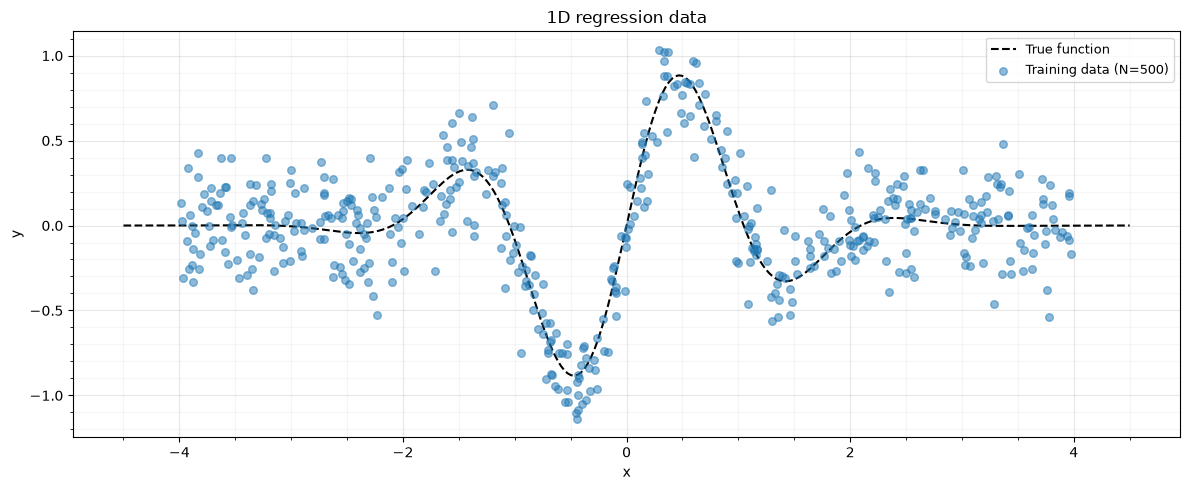

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_plot, f_true(x_plot), "k--", lw=1.5, label="True function", zorder=4)
ax.scatter(
    x_train,
    y_train,
    s=30,
    c="C0",
    alpha=0.5,
    label="Training data (N=500)",
    zorder=5,
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9)
ax.set_title("1D regression data")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## The kernel

A kernellib kernel is an immutable equinox module whose hyperparameters are plain arrays. Calling it on two input sets returns the Gram matrix; `gram(X)` is shorthand for `k(X, X)`.

In [6]:
kernel = kl.RBF(lengthscale=0.8, variance=1.0)
noise_var = noise_std**2

K_full = kernel.gram(X_train)
print(kernel)
print(f"Full Gram matrix: {K_full.shape}")

RBF(lengthscale=weak_f64[], variance=weak_f64[])
Full Gram matrix: (500, 500)


## Nyström approximation

We place $M$ inducing points on an evenly spaced grid, evaluate the two kernel blocks with the same kernel object, and hand them to `kl.nystrom_operator`.

In [7]:
m_inducing = 30
Z = jnp.linspace(-4.0, 4.0, m_inducing)[:, None]

K_XZ = kernel(X_train, Z)
K_ZZ_op = lx.MatrixLinearOperator(kernel.gram(Z))

K_nys = kl.nystrom_operator(K_XZ, K_ZZ_op)
print(f"Nyström operator type: {type(K_nys).__name__}, rank {K_nys.U.shape[1]}")

Nyström operator type: LowRankUpdate, rank 30


### Approximation quality

With 30 inducing points spaced well below the lengthscale of 0.8, the RBF kernel is almost exactly low rank on this interval, so the Nyström error is at round-off level.

In [8]:
K_nys_dense = K_nys.as_matrix()
frob_error = jnp.linalg.norm(K_full - K_nys_dense, "fro")
frob_relative = frob_error / jnp.linalg.norm(K_full, "fro")

print(f"Frobenius norm error:   {frob_error:.2e}")
print(f"Relative Frobenius err: {frob_relative:.2e}")

Frobenius norm error:   2.13e-08
Relative Frobenius err: 1.04e-10


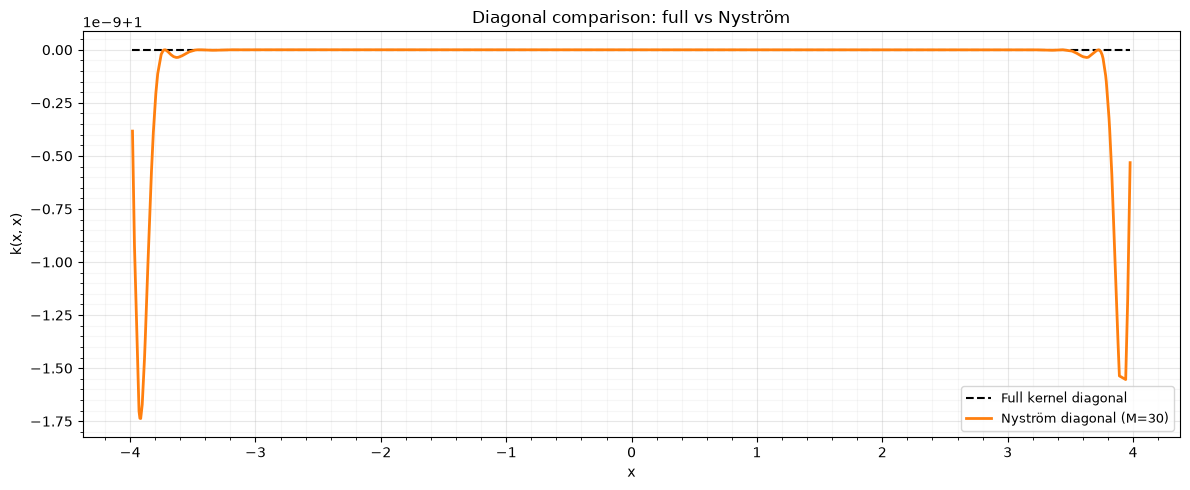

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_train, kernel.diag(X_train), "k--", lw=1.5, label="Full kernel diagonal")
ax.plot(
    x_train,
    jnp.diag(K_nys_dense),
    color="C1",
    lw=2,
    label=f"Nyström diagonal (M={m_inducing})",
)
ax.set_xlabel("x")
ax.set_ylabel("k(x, x)")
ax.legend(fontsize=9)
ax.set_title("Diagonal comparison: full vs Nyström")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

### GP regression through the Nyström operator

The system to solve is $(K_{\mathrm{nys}} + \sigma^2 I)\,\alpha = y$. Swapping the Nyström operator's zero base for $\sigma^2 I$ keeps it a `LowRankUpdate`, so `gaussx.solve` dispatches to the Woodbury identity at $O(NM^2)$ cost instead of $O(N^3)$.

In [10]:
K_noisy = gx.LowRankUpdate(
    base=lx.DiagonalLinearOperator(jnp.full(n_train, noise_var)),
    U=K_nys.U,
    d=K_nys.d,
    V=K_nys.V,
)
alpha_nys = gx.solve(K_noisy, y_train)

K_star = kernel(X_plot, X_train)
mu_nys = K_star @ alpha_nys

# Exact GP for reference, through the dense bridge
K_noisy_full = kl.to_operator(kernel, X_train, noise=noise_var)
alpha_full = gx.solve(K_noisy_full, y_train)
mu_full = K_star @ alpha_full

print(f"Max |mean_nys - mean_full|: {jnp.max(jnp.abs(mu_nys - mu_full)):.2e}")

Max |mean_nys - mean_full|: 5.00e-08


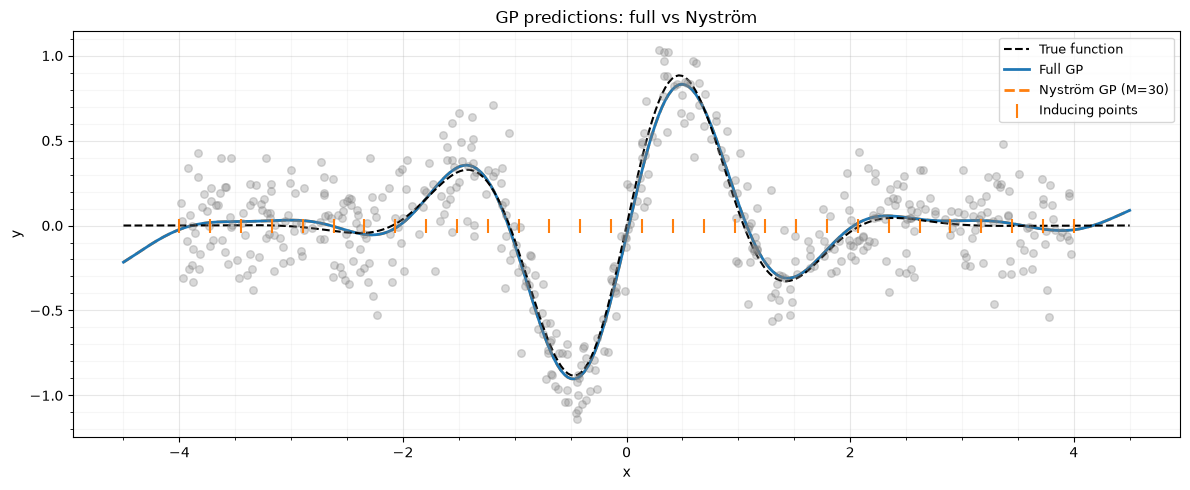

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x_plot, f_true(x_plot), "k--", lw=1.5, label="True function", zorder=4)
ax.plot(x_plot, mu_full, "C0-", lw=2, label="Full GP", zorder=3)
ax.plot(x_plot, mu_nys, "C1--", lw=2, label=f"Nyström GP (M={m_inducing})")
ax.scatter(
    x_train,
    y_train,
    s=30,
    c="grey",
    alpha=0.3,
    zorder=5,
)
ax.scatter(
    Z[:, 0],
    jnp.zeros(m_inducing),
    marker="|",
    s=100,
    c="C1",
    zorder=5,
    label="Inducing points",
)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=9)
ax.set_title("GP predictions: full vs Nyström")
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
ax.minorticks_on()
plt.tight_layout()
plt.show()

## Random Fourier features

For the RBF kernel we sample $\omega \sim \mathcal{N}(0, \ell^{-2} I)$ and $b \sim \mathrm{Uniform}(0, 2\pi)$ by hand here, reading $\ell$ off the kernel object. Drawing frequencies from a kernel's spectral density directly (`sample_frequencies`) and the `RandomFourierFeatures` feature map are planned for kernellib's spectral release.

In [12]:
D_rff = 500
k_omega, k_b = jax.random.split(jax.random.PRNGKey(99))
omega = jax.random.normal(k_omega, (D_rff, 1)) / kernel.lengthscale
b = jax.random.uniform(k_b, (D_rff,), minval=0.0, maxval=2.0 * jnp.pi)

K_rff = kl.rff_operator(X_train, omega, b)
print(f"RFF operator type: {type(K_rff).__name__}, rank {K_rff.U.shape[1]}")

K_rff_dense = K_rff.as_matrix()
frob_rff_rel = jnp.linalg.norm(K_full - K_rff_dense, "fro") / jnp.linalg.norm(
    K_full, "fro"
)
print(f"RFF relative Frobenius error (D={D_rff}): {frob_rff_rel:.4f}")

RFF operator type: LowRankUpdate, rank 500
RFF relative Frobenius error (D=500): 0.1189


### Convergence with the number of features

The Monte Carlo error of the RFF estimate shrinks at the $O(1/\sqrt{D})$ rate, so each tenfold increase in $D$ should cut the error by about $\sqrt{10} \approx 3.2$. A single draw is noisy, so we average the error over five independent draws per $D$.

In [13]:
D_values = [100, 1000, 10000]
n_draws = 5
norm_full = jnp.linalg.norm(K_full, "fro")


def rff_error(D, seed):
    k_o, k_bb = jax.random.split(jax.random.PRNGKey(seed))
    om = jax.random.normal(k_o, (D, 1)) / kernel.lengthscale
    bb = jax.random.uniform(k_bb, (D,), minval=0.0, maxval=2.0 * jnp.pi)
    K_approx = kl.rff_operator(X_train, om, bb).as_matrix()
    return float(jnp.linalg.norm(K_full - K_approx, "fro") / norm_full)


errors = []
for D in D_values:
    errs = [rff_error(D, seed) for seed in range(n_draws)]
    errors.append(sum(errs) / n_draws)
    print(f"  D = {D:6d}  |  mean relative error = {errors[-1]:.4f}")
ratios = [errors[i] / errors[i + 1] for i in range(len(errors) - 1)]
print("Error ratio per tenfold D:", ", ".join(f"{r:.2f}" for r in ratios))

  D =    100  |  mean relative error = 0.2570


  D =   1000  |  mean relative error = 0.0605


  D =  10000  |  mean relative error = 0.0212
Error ratio per tenfold D: 4.25, 2.85


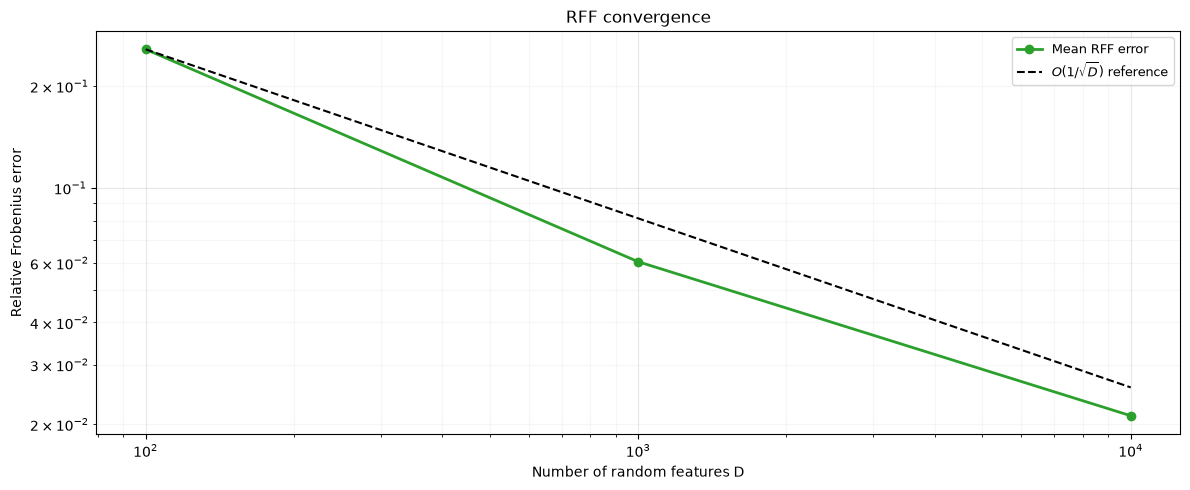

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.loglog(D_values, errors, "o-", color="C2", lw=2, label="Mean RFF error")
ref = errors[0] * (D_values[0] / jnp.asarray(D_values)) ** 0.5
ax.loglog(D_values, ref, "k--", lw=1.5, label=r"$O(1/\sqrt{D})$ reference")
ax.set_xlabel("Number of random features D")
ax.set_ylabel("Relative Frobenius error")
ax.set_title("RFF convergence")
ax.legend(fontsize=9)
ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.1)
plt.tight_layout()
plt.show()

The two ratios straddle $\sqrt{10}$; five draws per $D$ still leave some Monte Carlo noise.

### The three kernel matrices side by side

Every fifth row and column is shown, which keeps the structure visible at a fraction of the image size.

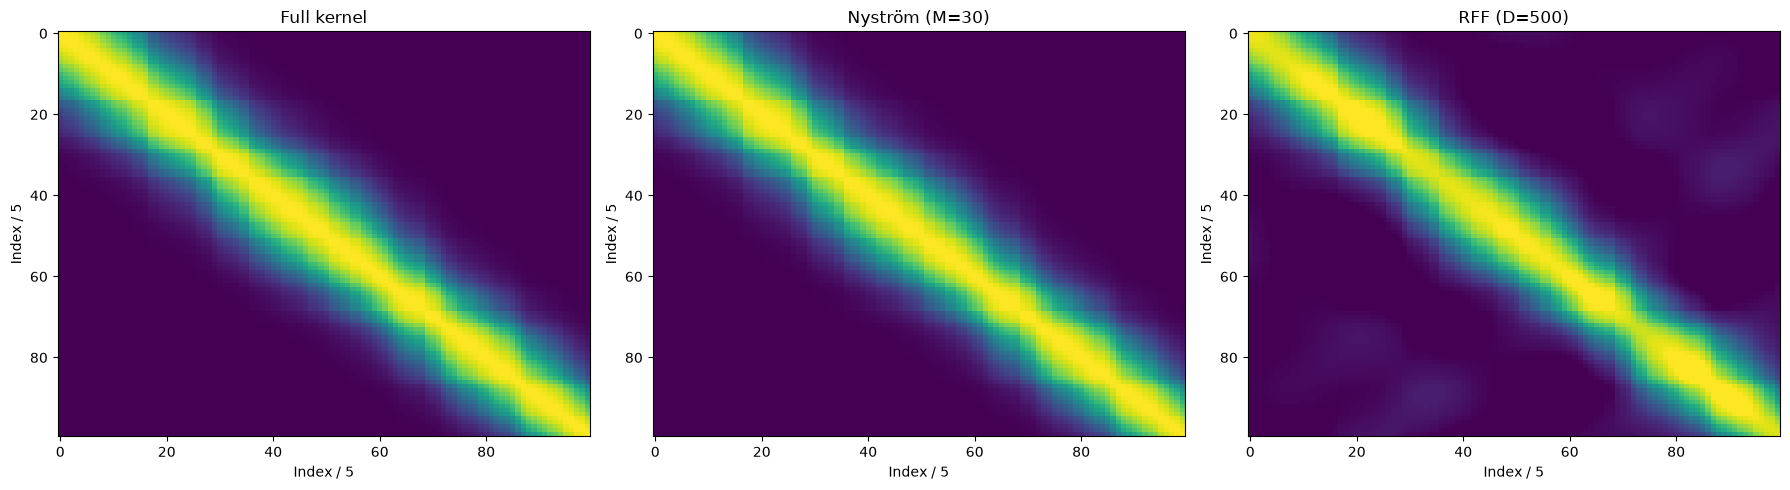

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
kw = dict(vmin=K_full.min(), vmax=K_full.max(), cmap="viridis", aspect="auto")

step = 5
axes[0].imshow(K_full[::step, ::step], **kw)
axes[0].set_title("Full kernel")
axes[1].imshow(K_nys_dense[::step, ::step], **kw)
axes[1].set_title(f"Nyström (M={m_inducing})")
axes[2].imshow(K_rff_dense[::step, ::step], **kw)
axes[2].set_title(f"RFF (D={D_rff})")
for ax in axes:
    ax.set_xlabel(f"Index / {step}")
    ax.set_ylabel(f"Index / {step}")
plt.tight_layout()
plt.show()

## Kernel centering

Kernel PCA, HSIC and CKA all work with the centered kernel $\tilde K = H K H$, where $H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top$. `F.centering_operator(n)` returns $H$ as a `LowRankUpdate` (identity plus a rank-one update), and `F.center_kernel` centers a kernel operator.

In [16]:
n = n_train
H_op = F.centering_operator(n)
H_manual = jnp.eye(n) - jnp.ones((n, n)) / n
print(f"Centering operator type: {type(H_op).__name__}")
print(f"H matches I - 11^T/n:    {jnp.allclose(H_op.as_matrix(), H_manual)}")

K_centered = F.center_kernel(lx.MatrixLinearOperator(K_full)).as_matrix()
print(
    f"Matches H K H:           {jnp.allclose(K_centered, H_manual @ K_full @ H_manual)}"
)
print(f"Max |row sum|:           {jnp.abs(K_centered.sum(axis=1)).max():.2e}")

Centering operator type: LowRankUpdate
H matches I - 11^T/n:    True


Matches H K H:           True
Max |row sum|:           4.13e-14


## HSIC and CKA: independence testing

The Hilbert-Schmidt Independence Criterion measures dependence between two variables through their kernel embeddings:

$$\mathrm{HSIC}_b(X, Y) = \frac{1}{n^2} \operatorname{tr}(K_x H K_y H)$$

With characteristic kernels it is zero in the population exactly when the variables are independent. The biased estimator above is always non-negative, so for independent samples it sits slightly above zero. The unbiased estimator of Song et al. (2012) removes that $O(1/n)$ bias and fluctuates around zero instead. Centered kernel alignment (CKA) normalises HSIC to $[0, 1]$ so values are comparable across kernels and scales.

We compare a dependent pair $(x, y = x + \epsilon)$ with an independent pair $(x, z)$.

In [17]:
k1, k2, k3 = jax.random.split(jax.random.PRNGKey(7), 3)
n_hsic = 200
x = jax.random.normal(k1, (n_hsic, 1))
y = x + 0.3 * jax.random.normal(k2, (n_hsic, 1))
z = jax.random.normal(k3, (n_hsic, 1))

k_unit = kl.RBF(lengthscale=1.0)


def gram_op(X):
    return lx.MatrixLinearOperator(k_unit.gram(X), lx.symmetric_tag)


K_x, K_y, K_z = gram_op(x), gram_op(y), gram_op(z)

In [18]:
rows = [("(x, y) dependent", K_x, K_y), ("(x, z) independent", K_x, K_z)]
print(f"{'pair':<20} {'HSIC biased':>12} {'HSIC unbiased':>14} {'CKA':>8}")
for name, A, B in rows:
    h_b = F.hsic(A, B)
    h_u = F.hsic(A, B, estimator="unbiased")
    c = F.cka(A, B)
    print(f"{name:<20} {h_b:12.6f} {h_u:14.6f} {c:8.4f}")

pair                  HSIC biased  HSIC unbiased      CKA


(x, y) dependent         0.055927       0.055716   0.8198
(x, z) independent       0.002026       0.001249   0.0291


## MMD: two-sample testing

The maximum mean discrepancy measures the distance between two distributions in a reproducing kernel Hilbert space:

$$\mathrm{MMD}^2(P, Q) = \mathbb{E}[k(x, x')] + \mathbb{E}[k(y, y')] - 2\,\mathbb{E}[k(x, y)]$$

`F.mmd_squared` takes the three kernel blocks as plain arrays. We compare $P = \mathcal{N}(0, 1)$ with $Q = \mathcal{N}(1, 1)$, and $P$ with a second sample from $P$.

In [19]:
k1, k2, k3 = jax.random.split(jax.random.PRNGKey(13), 3)
n_mmd = 200
x_p = jax.random.normal(k1, (n_mmd, 1))
y_q = jax.random.normal(k2, (n_mmd, 1)) + 1.0
x_p2 = jax.random.normal(k3, (n_mmd, 1))

mmd_diff = F.mmd_squared(k_unit.gram(x_p), k_unit.gram(y_q), k_unit(x_p, y_q))
mmd_same = F.mmd_squared(k_unit.gram(x_p), k_unit.gram(x_p2), k_unit(x_p, x_p2))

print(f"MMD^2(P, Q) different: {mmd_diff:.6f}")
print(f"MMD^2(P, P) same:      {mmd_same:.6f}")

MMD^2(P, Q) different: 0.148538
MMD^2(P, P) same:      0.004874


## Summary

| Function | Output | Cost |
|----------|--------|------|
| `kl.nystrom_operator(K_XZ, K_ZZ_op)` | `LowRankUpdate` | $O(NM^2)$ |
| `kl.rff_operator(X, omega, b)` | `LowRankUpdate` | $O(ND)$ |
| `F.centering_operator(n)` | `LowRankUpdate` | $O(n)$ |
| `F.center_kernel(K)` | `MatrixLinearOperator` | $O(n^2)$ |
| `F.hsic(K, L, estimator=...)`, `F.cka(K, L)` | scalar | $O(n^2)$ |
| `F.mmd_squared(K_xx, K_yy, K_xy)` | scalar | $O(n^2)$ |

**Key takeaways:**

- One kernel object builds every Gram block, so the approximations and the exact GP share hyperparameters by construction.
- Nyström and RFF both return `gaussx.LowRankUpdate`, so solves and log-determinants go through Woodbury in gaussx automatically.
- The matrix-level statistics live in `kernellib.functional`; the unbiased HSIC estimator removes the small positive bias the biased one shows on independent data, and CKA puts dependence on a $[0, 1]$ scale.